# Modelling carbonflation in the EU
This notebook models the impact of carbon price increases on inflation in different EU countries. 

@author: wirth 2026


## Loading Figaro IO tables
First, we have to load the Figaro database.

In [416]:
import os
import sys
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import eurostat
from itertools import product
import pickle
import gzip
import logging
import warnings

# Add local directory to sys.path via relative path
from mrio_toolbox import MRIO, Part, multi_scale_mapping

# Suppress warnings about duplicate dimension names specific UserWarnings from xarray.namedarray
logging.getLogger("mrio_toolbox._parts._Part").setLevel(logging.ERROR)
warnings.filterwarnings("ignore", category=UserWarning, module=r"xarray\.namedarray\.core")


############################
# Set script-wide parameters
############################

year = 2024  # Set the year for the analysis
country_coverage = "eu27_without_mt_si_lv_cy" 
emission_coverage = "ets1and2" # coverage options: "ets1", "ets2" "ets1and2", "all" (for all emissions)
price_scenario = "ets1and2-low"
figure_path = "../figures"

# load figaro
figaro_file_path = os.path.abspath(f"../data/figaro io/formatted io/figaro_year{year}_aggregated_{country_coverage}.nc")
figaro = MRIO(file= figaro_file_path)
countries = figaro.labels["countries"]
sectors = figaro.labels["sectors"]

## Check table balance

In [417]:
T = figaro.t # inter industry transactions
Y = figaro.y # final demand
V = figaro.va# value added
S = figaro.sup # supply table
M = T["ROW", "all"] # imports are defined as all T matrix entries with ROW on the vertical axis
E = T["all", "ROW"] # exports are defined as all T matrix entries with ROW on the horizontal axis

# Transform units from million euros to euros. WARNING: Don't run this cell multiple times, otherwise the values will be scaled up by 1e6 each time.
T = T * 1e6
Y = Y * 1e6
V = V * 1e6
S = S * 1e6
M = M * 1e6
E = E * 1e6

# before removing ROW
x_t1 = T.sum(axis = 0) + V.sum(axis = 0)
x_t2 = T.sum(axis = 1) + Y.sum(axis = 1)
x_s = S.sum(axis = 0)

print("First balance: iT + iV = (Ti + Yi)'")
print((x_t1 - x_t2).to_pandas().describe())
print()
print("Second balance: iS = iT + iV")
print((x_s - x_t1).to_pandas().describe())
print()

# Exclude ROW 
if "ROW" in countries:
    countries.remove("ROW") 

T = T[[[countries], "all"], [[countries], "all"]]
Y = Y[[countries], "all"]
V = V["all", [countries, "all"]]
S = S[[[countries], "all"], [[countries], "all"]]
M = M["all", [countries]]
E = E[[countries], "all"]

# after removing ROW
x_t1 = T.sum(axis = 0) + V.sum(axis = 0) + M.sum(axis = 0) # remove inter-industry ROW trade by selecting only countries other than ROW
x_t2 = T.sum(axis = 1) + Y.sum(axis = 1) + E.sum(axis = 1) # remove inter-industry ROW trade by selecting only countries other than ROW
x_s = S.sum(axis = 0)

print("First balance after ROW removal: iT + iV = (Ti + Yi)'")
print((x_t1 - x_t2).to_pandas().describe())
print()
print("Second balance after ROW removal: iS = iT + iV")
print((x_s - x_t1).to_pandas().describe())

# take any gross output computation as X
X = x_t1

First balance: iT + iV = (Ti + Yi)'
                 0
count  1536.000000
mean     -0.000002
std       0.000092
min      -0.001953
25%       0.000000
50%       0.000000
75%       0.000000
max       0.001953

Second balance: iS = iT + iV
                  0
count  1.536000e+03
mean   1.218223e+05
std    3.363458e+05
min   -1.900000e+04
25%    3.400000e+04
50%    5.500000e+04
75%    8.100000e+04
max    2.369000e+06

First balance after ROW removal: iT + iV = (Ti + Yi)'
                  0
count  1.472000e+03
mean   8.422395e-09
std    3.631187e-07
min   -7.629395e-06
25%    0.000000e+00
50%    0.000000e+00
75%    0.000000e+00
max    7.629395e-06

Second balance after ROW removal: iS = iT + iV
                   0
count    1472.000000
mean    54964.673913
std     31146.199878
min    -19000.000000
25%     33750.000000
50%     53000.000000
75%     76000.000000
max    146000.000000


We see that on absolute terms, the tables are balanced and that the balance also holds when removing ROW. The maximum absolute imbalance after removing ROW is 148 000 €, which is still small compared to Malta's GDP of 23 billion € in 2024. 

In [418]:
names = [f"{c} + {s}" for c, s in  product(x_s.labels["countries"], x_s.labels["sectors"])]
diff = x_s.data - X.data
relative_diff = diff / X.data * 100  # Calculate relative difference in percent
balancing_df = pd.DataFrame({"names": names, "diff": diff, "relative diff": relative_diff, "x_t": X.data, "x_s": x_s.data})
average_relative_diff = balancing_df["relative diff"].mean()
print(f"The average relative difference between the supply and IO table gross output is {average_relative_diff:.4f} percent")
print(f"The median relative difference between the supply and IO table gross output is {balancing_df['relative diff'].median():.4f} percent")
print(f"The maximum relative difference between the supply and IO table gross output is {balancing_df['relative diff'].max():.4f} percent")

balancing_df.sort_values(by="relative diff", ascending=False, inplace=True)
balancing_df

The average relative difference between the supply and IO table gross output is 0.0079 percent
The median relative difference between the supply and IO table gross output is 0.0008 percent
The maximum relative difference between the supply and IO table gross output is 0.5734 percent


,names,diff,relative diff,x_t,x_s
1035,LU + Manufacture of basic pharmaceutical produ...,75000.0,0.573394,13080000.0,13155000.0
1410,SK + Fishing and aquaculture,78000.0,0.529172,14740000.0,14818000.0
1044,LU + Manufacture of other transport equipment,65000.0,0.501621,12958000.0,13023000.0
1025,LU + Forestry and logging,74000.0,0.473812,15618000.0,15692000.0
1084,LU + Repair of computers and personal and hous...,111000.0,0.395468,28068000.0,28179000.0
...,...,...,...,...,...
1279,PT + Activities of extraterritorial organisati...,0.0,NaN,0.0,0.0
1342,RO + Activities of households as employers; un...,0.0,NaN,0.0,0.0
1343,RO + Activities of extraterritorial organisati...,0.0,NaN,0.0,0.0
1407,SE + Activities of extraterritorial organisati...,0.0,NaN,0.0,0.0


We see that also in relative terms, there are no big discrepancies and the tables can be used as is. 

## Load emission coverage
Next, we compute emission intensities for the ETS1 and ETS2 based on the emission satellite accounts from the multi-scale-mapping algorithm. We start by collecting a list of covered emission categories.

Note: ets1 and ets2 have overlapping coverage, e.g. 1.A.1.a is contained in both. So if we want to disaggregate, then we should rather just use the effect of ets1 and the total effect and the difference is the effect of ets2. But if we compute the effect of ets1 plus that of ets2 we double count the overlapping emission categories. 

In [419]:
qt_coverage = figaro.qt.labels["Emission categories"]

ets1_coverage = pd.read_excel("../data/sectoral coverage/Emission Coverage ETS.xlsx", sheet_name="ETS1")["IPCC Source Category"].dropna().tolist()
ets1_coverage.sort()
ets1_coverage = [cat for cat in ets1_coverage if cat in qt_coverage] # remove categories that are not in qt_coverage

ets2_coverage = pd.read_excel("../data/sectoral coverage/Emission Coverage ETS.xlsx", sheet_name="ETS2")["IPCC Source Category"].dropna().tolist()
ets2_coverage.sort()
ets2_coverage = [cat for cat in ets2_coverage if cat in qt_coverage]

ets1and2_coverage = list(set(ets1_coverage).union(set(ets2_coverage)))
ets1and2_coverage.sort()

complete_coverage = []
for cat in (qt_coverage):
    if not any([cat.startswith(parent + ".") for parent in qt_coverage]):
        complete_coverage.append(cat)
complete_coverage.remove("M.0.EL") # otherwise double counting 

Then, we load the emissions from Figaro and build different Q matrices based on the coverage

In [420]:
figaro.qt = figaro.qt * 1000 # convert from kt CO2 to t CO2
Q_ets1 = figaro.qt[["CO2", ets1_coverage], "all"].sum(on = "Emission categories") # Emissions covered from ETS1
Q_ets2 = figaro.qt[["CO2", ets2_coverage], "all"].sum(on = "Emission categories") # Emissions covered from ETS1 and ETS2
Q_ets1and2 = figaro.qt[["CO2", ets1and2_coverage], "all"].sum(on = "Emission categories") # Emissions covered from ETS1 and ETS2
Q_all = figaro.qt[["CO2", complete_coverage], "all"].sum(on = "Emission categories") # All CO2 emissions

Q_ets1 = Q_ets1[[countries], ]
Q_ets2 = Q_ets2[[countries], ]
Q_ets1and2 = Q_ets1and2[[countries],]
Q_all = Q_all[[countries],]

In [421]:
# Compute technical coefficients and shares from partitioned table without ROW
A = T / X # technical coefficients
q_ets1 = Q_ets1 / X
q_ets2 = Q_ets2 / X
q_ets1and2 = Q_ets1and2 / X
q_all = Q_all / X


# treat nans and infs
A.data = np.nan_to_num(A.data, nan=0.0)
L = A.leontief_inversion()

q_ets1.data = np.nan_to_num(q_ets1.data, nan=0.0, posinf=0.0)
q_ets2.data = np.nan_to_num(q_ets2.data, nan=0.0, posinf=0.0)
q_ets1and2.data = np.nan_to_num(q_ets1and2.data, nan=0.0, posinf=0.0)
q_all.data = np.nan_to_num(q_all.data, nan=0.0, posinf=0.0)

# define q based on coverage option. Later we can extend this in order to disaggregate and use multiple q's
match emission_coverage:
    case "ets1":
        Q = Q_ets1
        q = q_ets1
    case "ets2":
        Q = Q_ets2
        q = q_ets2
    case "ets1and2":
        Q = Q_ets1and2
        q = q_ets1and2
    case "all":
        Q = Q_all
        q = q_all
    case _:
        raise ValueError(f"Invalid coverage option: {emission_coverage}. Choose from 'ets1', 'ets1and2', or 'all'.")

## Print emission coverage

Text(0.5, 1.0, 'Total CO2 emissions by country and coverage')

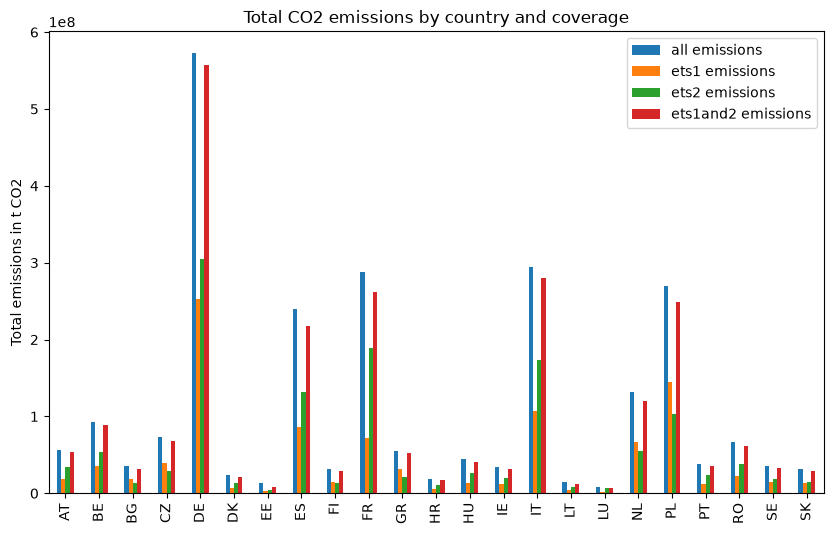

In [422]:
# Print emission coverage by country
df = pd.DataFrame(index = countries)
df["all emissions"] = Q_all.sum(on = "sectors").to_pandas()
df["ets1 emissions"] = Q_ets1.sum(on = "sectors").to_pandas()
df["ets2 emissions"] = Q_ets2.sum(on = "sectors").to_pandas()
df["ets1and2 emissions"] = Q_ets1and2.sum(on = "sectors").to_pandas()

df.plot(kind="bar", figsize=(10, 6))
plt.ylabel("Total emissions in t CO2")
plt.title("Total CO2 emissions by country and coverage")

In [423]:
# print average emission coverage
df["share of emissions covered"] = (df["ets1and2 emissions"] / df["all emissions"])
df["share of emissions covered"].describe()

count    23.000000
mean      0.910082
std       0.077300
min       0.582087
25%       0.906124
50%       0.921156
75%       0.942253
max       0.991665
Name: share of emissions covered, dtype: float64

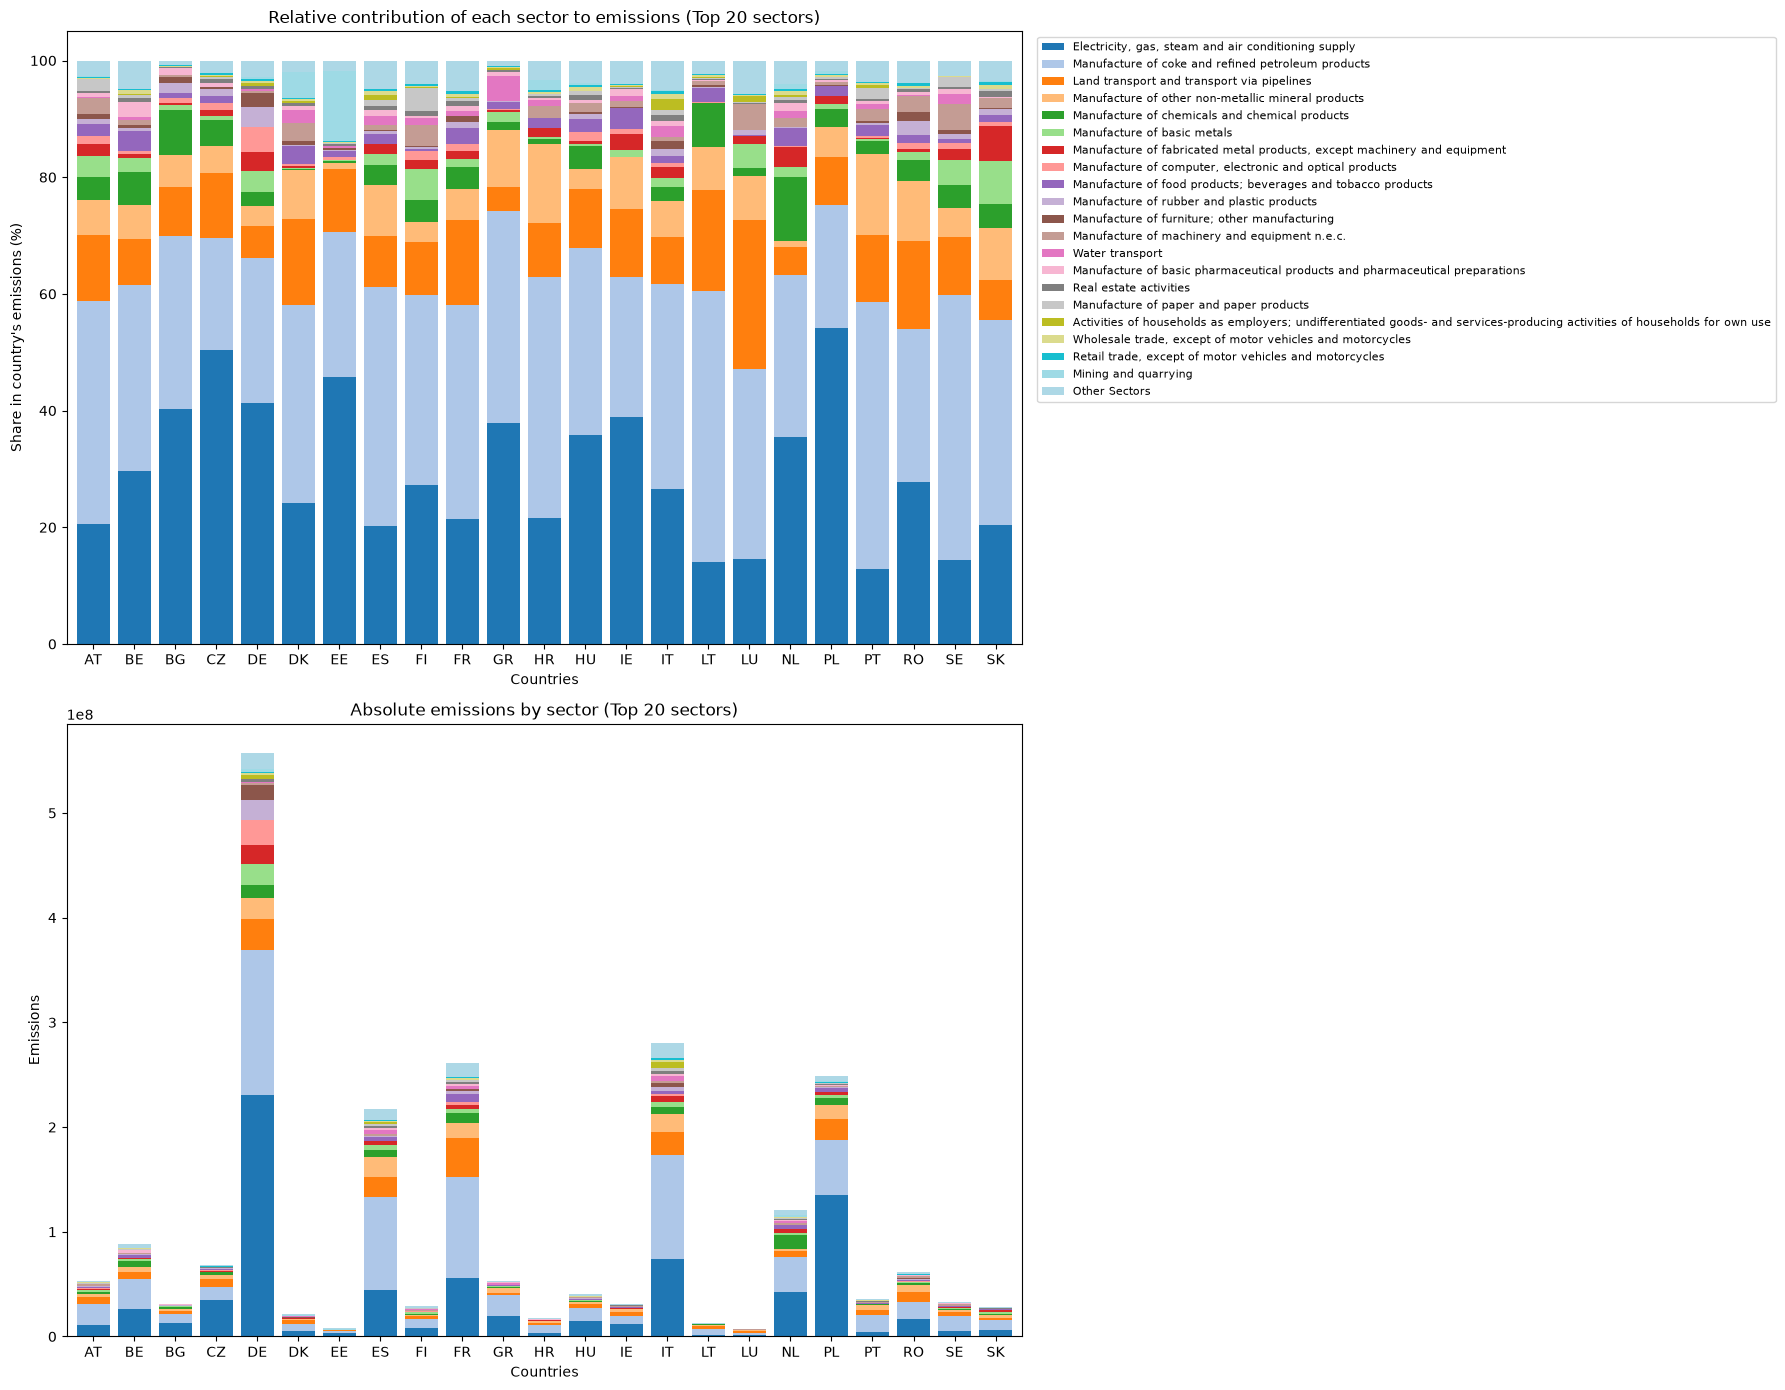

In [424]:
df = Q_ets1and2.develop().to_pandas()


top20 = df.sum().nlargest(20).index
pct = df.div(df.sum(axis=1), axis=0) * 100
plot_df = pct[top20].copy()
plot_df["Other Sectors"] = pct.drop(columns=top20).sum(axis=1)

abs_df = df[top20].copy()
abs_df["Other Sectors"] = df.drop(columns=top20).sum(axis=1)

cmap = plt.get_cmap("tab20")
colors = [cmap(i) for i in range(20)] + ["lightblue"]

fig, axes = plt.subplots(2, 1, figsize=(18, 14))

for ax, data, title, ylabel in zip(
    axes,
    [plot_df, abs_df],
    ["Relative contribution of each sector to emissions (Top 20 sectors)",
     "Absolute emissions by sector (Top 20 sectors)"],
    ["Share in country's emissions (%)", "Emissions"]
):
    data.plot(kind="bar", stacked=True, ax=ax, color=colors, width=0.8, legend=False)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Countries")
    ax.set_xticklabels(df.index, rotation=0)

axes[0].legend(plot_df.columns, bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

## Carbon model

To model the impact of the ETS on consumer prices, we first model the impact on sectoral prices and then use bridging matrices and consumption baskets to transform sectoral inflation to consumer price inflation. 

Sectoral inflation is computed with a cost push model. Consider the basic price model: 

$$ x' = i' Z + v'$$

with $x$ as the output column vector, $Z$ the intermediate demand matrix, $i$ the summation operator, i.e. a column vector of ones, and $v$ the value added expenditures vector. In words, this equation states that total outlays have to be equal to total output. 

Substituting $Z = A \hat X $ leads to: 

$$ x' = i' A \hat X + v'$$

To express everything per unit of output, we postmultiply by $\hat x ^ {-1}$: 

$$ i' = i' A + v_c'$$

We follow the notation in Miller and Blair and define $v_c' = v' \hat x ^{-1}$ as the value added costs per unit of output. As prices equal production costs (which include profits, wages, imports, taxes etc), each price is equal to 1 and we can write: 

$$ p' = p' A + v_c'$$

Re-arranging and applying the Leontief inverse yields:

$$ p' = v_c' (I - A)^{-1} = v_c'L$$

If we write the value added vector as a diagonal matrix, then the price vector becomes a price matrix. This allows us to later distinguish between the origin and the destination of a price shock and thus to capture imported and exported inflationary pressures. 

$$ P = \hat v_c (I - A)^{-1} = \hat v_c L$$


If we apply a carbon price, this will mechanically increase the value added component $V_c'L$ and vla the Leontief inverse increase the overall price level in the economy. Note that 

$$\Delta P  = \Delta \hat v_c L$$

and $ \Delta \hat v_c = \Delta (\hat \tau \hat q) $ with $\tau$ the column vector of carbon prices and $ \hat q = \hat Q \hat X ^{-1} $ the vector of emission intensities per unit of output. 

So we arrive at the final model for sectoral carbon prices with:

$$\Delta P  = \Delta \hat \tau \hat q L$$

The structure of the $\Delta P$ matrix can be read similar to that of a multi-regional intermediate demand matrix:

$$
\Delta P = \begin{bmatrix}
\Delta p_{1,1 \rightarrow 1,1} & \Delta p_{1,1 \rightarrow 1,2} & \cdots & \Delta p_{1,1 \rightarrow 1,S} & \Delta p_{1,1 \rightarrow 2,1} & \cdots & \Delta p_{1,1 \rightarrow C,S} \\
\Delta p_{1,2 \rightarrow 1,1} & \Delta p_{1,2 \rightarrow 1,2} & \cdots & \Delta p_{1,2 \rightarrow 1,S} & \Delta p_{1,2 \rightarrow 2,1} & \cdots & \Delta p_{1,2 \rightarrow C,S} \\
\vdots & \vdots & \ddots & \vdots & \vdots & \ddots & \vdots \\
\Delta p_{1,S \rightarrow 1,1} & \Delta p_{1,S \rightarrow 1,2} & \cdots & \Delta p_{1,S \rightarrow 1,S} & \Delta p_{1,S \rightarrow 2,1} & \cdots & \Delta p_{1,S \rightarrow C,S} \\
\Delta p_{2,1 \rightarrow 1,1} & \Delta p_{2,1 \rightarrow 1,2} & \cdots & \Delta p_{2,1 \rightarrow 1,S} & \Delta p_{2,1 \rightarrow 2,1} & \cdots & \Delta p_{2,1 \rightarrow C,S} \\
\vdots & \vdots & \ddots & \vdots & \vdots & \ddots & \vdots \\
\Delta p_{C,S \rightarrow 1,1} & \Delta p_{C,S \rightarrow 1,2} & \cdots & \Delta p_{C,S \rightarrow 1,S} & \Delta p_{C,S \rightarrow 2,1} & \cdots & \Delta p_{C,S \rightarrow C,S} \\
\end{bmatrix}
$$

where each element $\Delta p_{c,s \rightarrow c',s'}$ denotes the destination of a price increase in an originating country-sector combination $(c,s)$ on the price of another country-sector combination $(c',s')$ for sectors $s \in (1, ..., S)$ and countries $c \in (1, ... , C)$ with S and C being the respective number of sectors and countries in the model. Thus, the rows show the downstream origin of a price shock while the columns show its upstream destination. For example, the first row of the matrix corresponds to a price increase in the first sector of the first country, while all the elements of that first row depict the effect on every other country-sector combination. The diagonal elements are the destination of a carbon price increase on the price of the country-sector combination itself.

We can separately compute this model with carbon price changes for the ETS1 and the ETS2. Whenever a sector $s$ in a country $c$ is not covered by a carbon taxing scheme, it has a tax rate $\tau_{s,c} = 0$

In [425]:
# construct tau vector (one vertical axis with the two dimensions countries and sectors)
dtau = Part(labels = {"0": {"countries" : countries, "sectors" : sectors}}, name = "delta_tau")
price_changes = pd.read_excel("../data/carbon prices/carbon prices.xlsx", sheet_name="carbon_price_changes")
price_changes = price_changes.set_index("country")[price_scenario].to_dict()

for country in countries: 
    dtau[country] = price_changes[country]

# diagonalize delta tau
dtau_diag = dtau.diag()
q_diag = q_ets1and2.diag()

P = dtau_diag.mul(q_diag).mul(L)

# convert to percentage change
P = 100*P

## Transform industry inflation impact to hicp impact
### From NACE2 to CPA to COICOP to HICP
To get from the sectoral inflation to the CPI impact, we go throught he following steps: 
1. We now transform sectoral inflation impacts on the industry level to the product level using our market share matrix. 
2. Then, we transform this to the COICOP level using [this bridging matrix](https://www.sciencedirect.com/science/article/pii/S2352340920302894#ecom0002). We will assume that intertemporal stability of the briding coefficients for the year 2015 holds, following [Kronenberg 2011](https://io4.shaio.es/paper/pap15.pdf). 
3. Then, we will compute inflation impact using the hicp inflation weights from eurostat. 

We normalize the supply table and compute the market share matrix C by dividing each column of S by the respective column sum.

In [426]:
C = S / x_s
C.data = np.nan_to_num(C.data, nan=0.0) 

###  Harmonize hicp data
Aggregate residual categories CP122 to CP127 to harmonize Coicop labels between the datasets for hicp weights and the bridge matrix

In [427]:
# prepare hicp data
hicp = pd.read_csv("../data/HICP weights/estat_prc_hicp_inw_filtered_en.csv")
hicp = hicp[hicp["TIME_PERIOD"] == year]

# replace "EL" with "GR" for Greece
hicp["geo"] = hicp["geo"].replace({"EL": "GR"})

hicp["coicop"] = hicp["coicop"].replace({
    "CP122": "CP122_127",
    "CP123": "CP122_127",
    "CP124": "CP122_127",
    "CP125": "CP122_127",
    "CP126": "CP122_127",
    "CP127": "CP122_127"
})
hicp = hicp[hicp["geo"].isin(countries)]  # Filter for countries in the MRIO model
#hicp = hicp.groupby(["coicop", "geo", "TIME_PERIOD"], as_index=False)["OBS_VALUE"].sum()
hicp = hicp.groupby(["geo", "coicop", "TIME_PERIOD"], as_index=False)["OBS_VALUE"].sum()
coicop_labs = hicp["coicop"].drop_duplicates().to_list()

### Compute inflation impact

A note on the following matrixes: 
- dP_csd is the total euro-wide inflation caused by a specific sector in a specific country
  - dP_csd_d is its direct component (the inflation the sector caused on itself)
  - dP_csd_i is its indirect component
- dp_rec is the total euro-wide inflation that a specific sector in a specific country received from all other european sectors (and potentially imports from RoW)
  - dp_rec_d is its direct component and is equivalent to dP_csd_d
  - dp_rec_i is its indirect component

Later when cycling through the countries, we will also compute caused and received inflation only for national industries without cross-border inflation propagation to facilitate comparability with Weber et al.

In [428]:
# direct and indirect received and caused inflation in NACE classification
dP_csd = P.sum(axis=1).alias(data = P.sum(axis = 1))
dP_csd_d = dP_csd.alias(data = P.data.diagonal()) 
dP_csd_i = dP_csd.alias(data = dP_csd.data - dP_csd_d.data) 
dP_rec = P.sum(axis=0).alias(data = P.sum(axis = 0))
dP_rec_d = dP_csd_d
dP_rec_i = dP_csd.alias(data = dP_rec.data - dP_rec_d.data)

# convert to cpa classification
dP_rec_cpa = C.mul(dP_rec)
dP_rec_d_cpa = C.mul(dP_rec_d)
dP_rec_i_cpa = C.mul(dP_rec_i)

# Create empty part objects to store results in CCP and weighted CCP
coicop_labs = hicp["coicop"].drop_duplicates().to_list()

dP_rec_ccp = Part(labels = [[{"countries":countries, "ccp":coicop_labs}],])
dP_rec_d_ccp = Part(labels = [[{"countries":countries, "ccp":coicop_labs}],])
dP_rec_i_ccp = Part(labels = [[{"countries":countries, "ccp":coicop_labs}],])

sectoral_rec = Part(labels = [[{"countries":countries}],[{"sectors":sectors}]])
sectoral_rec_ccp = Part(labels = [[{"countries":countries, "ccp":coicop_labs}],])

# create new dataframe to store computed hicp inflation impacts 
df = pd.DataFrame(index = countries)
df["rec"] = dP_rec.sum(on="sectors").data
df["rec_d"] = dP_rec_d.sum(on="sectors").data
df["rec_i"] = dP_rec_i.sum(on="sectors").data

In [429]:
for country in countries:

    # prepare bridging matrix
    bridging_matrix_df = pd.read_excel("../data/CPA to COICOP mapping/bridging_matrix_2016.xlsx", sheet_name=country, header=0, index_col=0)
    bridging_matrix_df = bridging_matrix_df.drop('CP042',axis=1) # imputed rents are not in hicp data
    
    # append row for CPA_U so matrix multiplication works (CPA_U is always 0)
    series = np.zeros(len(bridging_matrix_df.columns), dtype=float)
    bridging_matrix_df.loc["CPA_U"] = series 
    
    # make new part object for the bridging matrix of each country
    data = bridging_matrix_df.to_numpy(dtype=float)
    cpa_labs = bridging_matrix_df.index.tolist()
    coicop_labs = bridging_matrix_df.columns.tolist()
    bridging_matrix = Part(data = data, name = "bridging_matrix", labels = [cpa_labs, coicop_labs])
    bridging_matrix = bridging_matrix.transpose()  # coicop labels on vertical axis
    bridging_matrix /= bridging_matrix.sum(axis=0)  # normalize
    bridging_matrix.data = np.nan_to_num(bridging_matrix.data, nan=0.0)
    
    # load hicp weights for the country
    hicp_weights = hicp[hicp["geo"] == country]["OBS_VALUE"].to_numpy()
    hicp_weights = hicp_weights / 1000 # normalize hicp weights to sum to 1
    
    # national-only received inflation in cpa
    dP_rec_nat = P[country, country].sum(axis=0).alias(data = P[country, country].sum(axis = 0))
    dP_rec_nat_cpa = C[country, country].mul(dP_rec_nat) 
    
    # cpa -> coicop classifcation
    dP_rec_ccp[country, "all"] = bridging_matrix.mul(dP_rec_cpa[country, "all"])
    dP_rec_d_ccp[country, "all"] = bridging_matrix.mul(dP_rec_d_cpa[country, "all"])
    dP_rec_i_ccp[country, "all"] = bridging_matrix.mul(dP_rec_i_cpa[country, "all"])
    dP_rec_nat_ccp = bridging_matrix.mul(dP_rec_nat_cpa[country, "all"])
    
    # coicop -> hicp 
    df.loc[country, "rec_hicp"] = hicp_weights @ dP_rec_ccp[country, "all"].data
    df.loc[country, "rec_d_hicp"] = hicp_weights @ dP_rec_d_ccp[country, "all"].data
    df.loc[country, "rec_i_hicp"] = hicp_weights @ dP_rec_i_ccp[country, "all"].data
    df.loc[country, "rec_nat_hicp"] = hicp_weights @ dP_rec_nat_ccp.data
    
    # average relative and absolute emission intensity of the country in tCO2 per million € output
    df.loc[country, "avg_q"] = q[country].sum(axis=0).data * 1e6
    df.loc[country, "avg_Q"] = Q[country].sum(axis=0).data * 1e6
    
    # sector-specific contribution to hicp exposure
    for sector in sectors:
        # shock each sector individually to see its exposure to HICP inflation from all other sectors
        rec_NACE = dP_rec.alias(data = np.zeros(dP_rec.shape))
        rec_NACE[country,sector] = dP_rec[country, sector]
        
        # nace -> cpa
        sectoral_rec_cpa = C.mul(rec_NACE)
        # cpa -> coicop
        sectoral_rec_ccp[country, "all"] = bridging_matrix.mul(sectoral_rec_cpa[country, "all"]) 
        # coicop -> hicp
        sectoral_rec[country, sector] = hicp_weights @ sectoral_rec_ccp[country, "all"].data
    
# imported inflation from other european countries    
df["rec_from_foreign"] = df["rec_hicp"] - df["rec_nat_hicp"]

### Adding GDP and population variables to main dataframe

In [430]:
if not os.path.exists("../data/sociodemographic_data/gdp_data.csv") or not os.path.exists("../data/sociodemographic_data/population_data.csv"):
    print("Sociodemographic data files not found. Downloading from Eurostat...")
    gdp_df = eurostat.get_data_df("nama_10_gdp") 
    pop_df = eurostat.get_data_df("demo_pjangroup")
    # save sociodemographic data to csv file
    path = "../data/sociodemographic_data"
    os.makedirs(path, exist_ok=True)  # Create directory if it doesn't exist
    gdp_df.to_csv(os.path.join(path, "gdp_data.csv"), index=False)
    pop_df.to_csv(os.path.join(path, "population_data.csv"), index=False)
else:
    # load sociodemographic data from csv files
    gdp_df = pd.read_csv("../data/sociodemographic_data/gdp_data.csv")
    pop_df = pd.read_csv("../data/sociodemographic_data/population_data.csv")

In [431]:
# rename EL to GR in both dataframes
gdp_df["geo\\TIME_PERIOD"] = gdp_df["geo\\TIME_PERIOD"].replace({"EL": "GR"})
pop_df["geo\\TIME_PERIOD"] = pop_df["geo\\TIME_PERIOD"].replace({"EL": "GR"})

gdp_df = gdp_df[
    (gdp_df["geo\\TIME_PERIOD"].isin(countries)) & # filter for the year 2022
    (gdp_df["na_item"] == "B1GQ") & # GDP (gross domestic product at market prices)
    (gdp_df["unit"] == "CP_MEUR") # current prices, million euro
    ][["geo\\TIME_PERIOD", "2022"]]

pop_df = pop_df[
    (pop_df["geo\\TIME_PERIOD"].isin(countries)) &
    (pop_df["age"] == "TOTAL") &
    (pop_df["sex"] == "T")
][["geo\\TIME_PERIOD", "2022"]].reset_index(drop=True)

df["GDP"] = gdp_df.set_index("geo\\TIME_PERIOD")["2022"].astype(float) 
df["POP"] = pop_df.set_index("geo\\TIME_PERIOD")["2022"].astype(float)
df["GDP_per_capita"] = df["GDP"] / df["POP"]

# Data analysis
Now we are ready to analyze our data. First we look not at the HICP itself but take a step back to our deltaP matrix in order to identify which sectors are most relevant for upstream inflation generation (horizontal sum of columns) or downstream inflation exposure (vertical sum of rows). 

## Inflation impact and exposure by sector


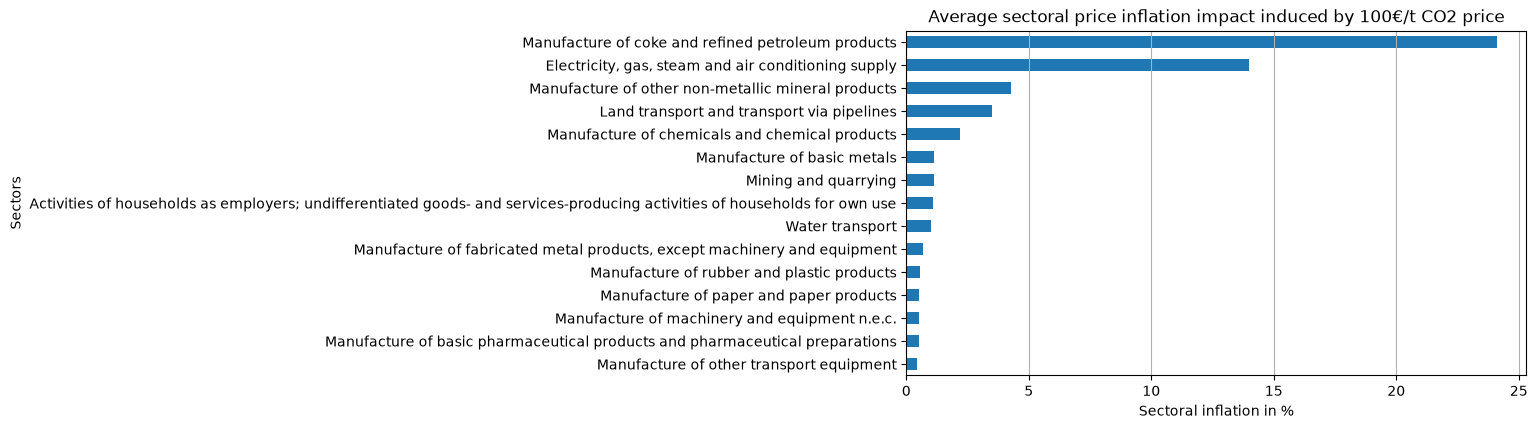

In [432]:
series = pd.Series(dP_csd.sum(on="countries").data, index = sectors).sort_values()/len(countries)
series = series.tail(15)

plt.figure(figsize=(8, len(sectors) * 0.07))
series.plot(kind="barh")
plt.xlabel("Sectoral inflation in %")
plt.ylabel("Sectors")
plt.title("Average sectoral price inflation impact induced by 100€/t CO2 price")
plt.grid(axis='x')
plt.savefig(os.path.join(figure_path, "hbar_sectoral_impact.png"), bbox_inches='tight', dpi=300)
plt.show()

<Figure size 800x320 with 0 Axes>

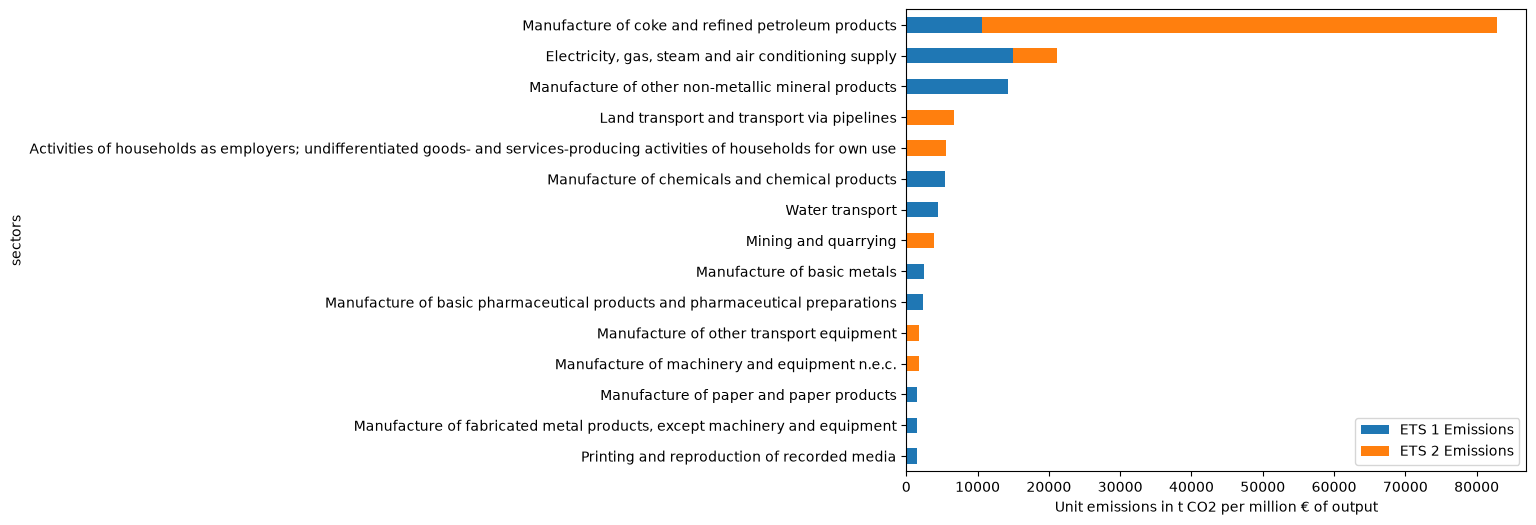

In [433]:
q_df = pd.DataFrame()
q_df["ETS 1 Emissions"] = q_ets1.sum(on="countries").to_pandas() * 1e6 # convert to tons of CO2 / million euros
q_df["ETS 1 and 2 Emissions"] = q_ets1and2.sum(on="countries").to_pandas() * 1e6  # convert to tons of CO2 / million euros
q_df["All Emissions"] = q_all.sum(on="countries").to_pandas() * 1e6  # convert to tons of CO2 / million euros
q_df["ETS 2 Emissions"] = q_df["ETS 1 and 2 Emissions"] - q_df["ETS 1 Emissions"]

plt.figure(figsize=(8, len(sectors) * 0.05))
ax = q_df.sort_values(by = ["ETS 1 and 2 Emissions"])[["ETS 1 Emissions", "ETS 2 Emissions"]].tail(15).plot(kind="barh", figsize=(8, 6), stacked=True)
plt.xlabel("Unit emissions in t CO2 per million € of output")
plt.savefig(os.path.join(figure_path, "hbar_unit_emissions.png"), bbox_inches='tight', dpi=300)
plt.show()

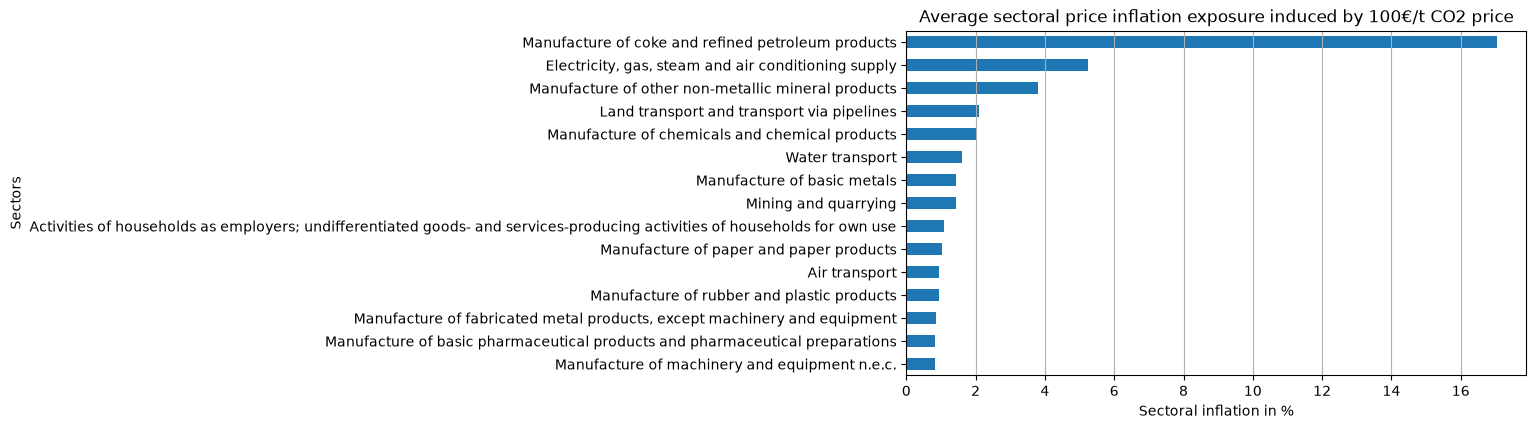

In [434]:
series = pd.Series(dP_rec.sum(on="countries").data, index = sectors).sort_values()/len(countries)
series = series.tail(15)

plt.figure(figsize=(8, len(sectors) * 0.07))
series.plot(kind="barh")
plt.xlabel("Sectoral inflation in %")
plt.ylabel("Sectors")
plt.title("Average sectoral price inflation exposure induced by 100€/t CO2 price")
plt.grid(axis='x')
plt.savefig(os.path.join(figure_path, "hbar_sectoral_exposure.png"), bbox_inches='tight', dpi=300)
plt.show()

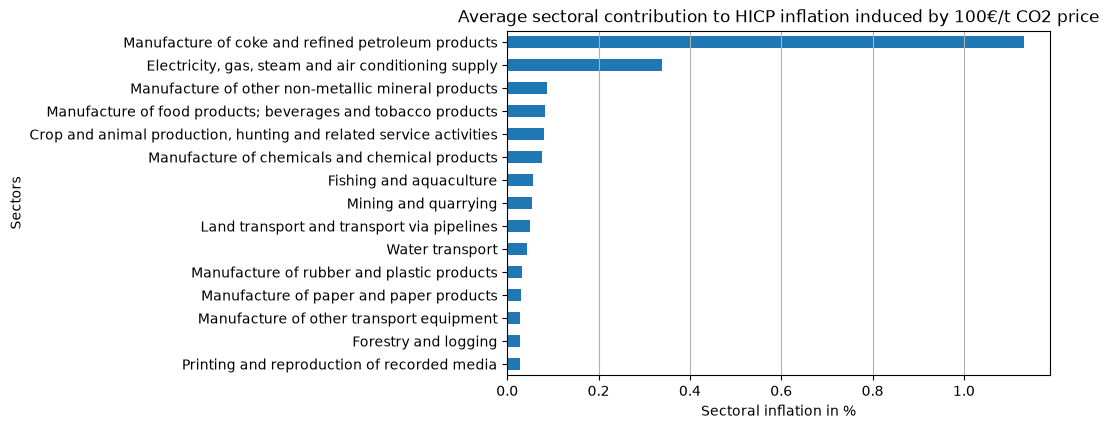

In [435]:
series = pd.Series(sectoral_rec.sum(axis=0).data, index = sectors).sort_values()/len(countries)
series = series.tail(15)

plt.figure(figsize=(7, len(sectors) * 0.07))
series.plot(kind="barh")
plt.xlabel("Sectoral inflation in %")
plt.ylabel("Sectors")
plt.title("Average sectoral contribution to HICP inflation induced by 100€/t CO2 price")
plt.grid(axis='x')
plt.savefig(os.path.join(figure_path, "hbar_sectoral_contribution_to_hicp.png"), bbox_inches='tight', dpi=300)
plt.show()

### Inflationary exposure per country by sector

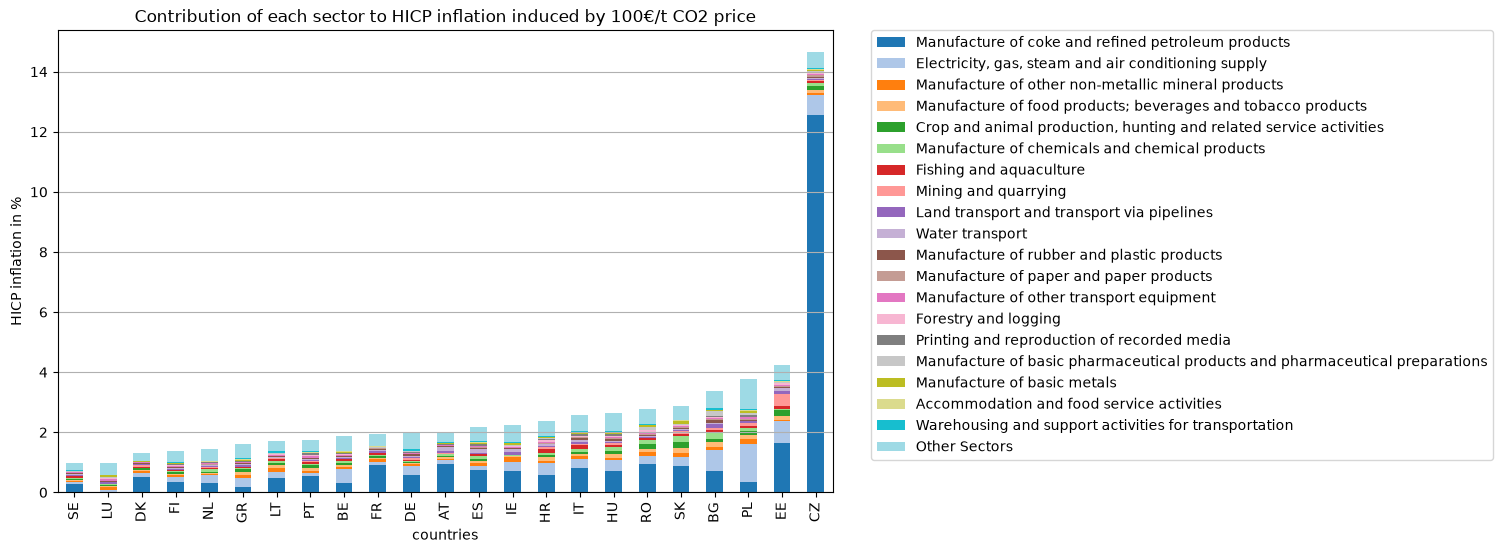

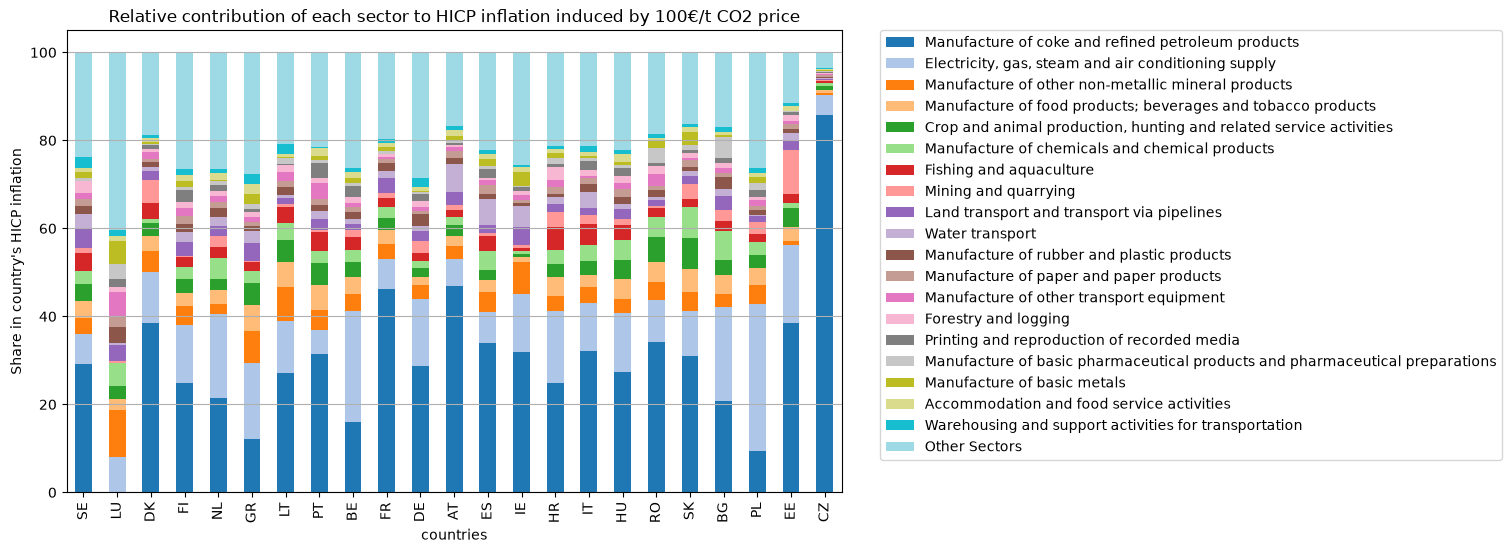

In [436]:
exposure_df = sectoral_rec.to_pandas()
exposure_df = exposure_df.transpose()
exposure_df["aggr_sectoral_exposure"] = exposure_df.sum(axis=1)
exposure_df = exposure_df.sort_values(by="aggr_sectoral_exposure", ascending=False)
top9 = exposure_df.head(19)
other = pd.DataFrame(exposure_df.iloc[19:].sum(axis=0)).transpose()
other.index = ["Other Sectors"]
exposure_df = pd.concat([top9, other])
exposure_df = exposure_df.drop(columns=["aggr_sectoral_exposure"])
exposure_df = exposure_df.transpose()
exposure_df["aggr_sectoral_exposure"] = exposure_df.sum(axis=1)
exposure_df = exposure_df.sort_values(by="aggr_sectoral_exposure", ascending=True)
normalized_exposure = exposure_df.div(exposure_df["aggr_sectoral_exposure"], axis=0) * 100  # Normalize to percentage
exposure_df = exposure_df.drop(columns=["aggr_sectoral_exposure"])


cmap = plt.get_cmap("tab20")
colors = [cmap(i) for i in range(exposure_df.shape[1])]

ax = exposure_df.plot(kind = "bar", stacked=True, figsize=(10, 6), color = colors)
ax.grid(axis='y')
plt.title("Contribution of each sector to HICP inflation induced by 100€/t CO2 price")
plt.ylabel("HICP inflation in %")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.savefig(os.path.join(figure_path, "bar_hicp_by_country_sector.png"), bbox_inches='tight', dpi=300)
plt.show()

normalized_exposure = normalized_exposure.drop(columns=["aggr_sectoral_exposure"])
ax = normalized_exposure.plot(kind = "bar", stacked=True, figsize=(10, 6), color = colors)
ax.grid(axis='y')
plt.title("Relative contribution of each sector to HICP inflation induced by 100€/t CO2 price")
plt.ylabel("Share in country's HICP inflation")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.savefig(os.path.join(figure_path, "bar_hicp_by_country_sector_normalized.png"), bbox_inches='tight', dpi=300)
plt.show()

### Inflation exposure by sector
Those are the downstream sectors most exposed to inflationary pressure from carbon taxes. EU-average with cross-country price propagation

### EU-wide inflation impact and exposure of each country

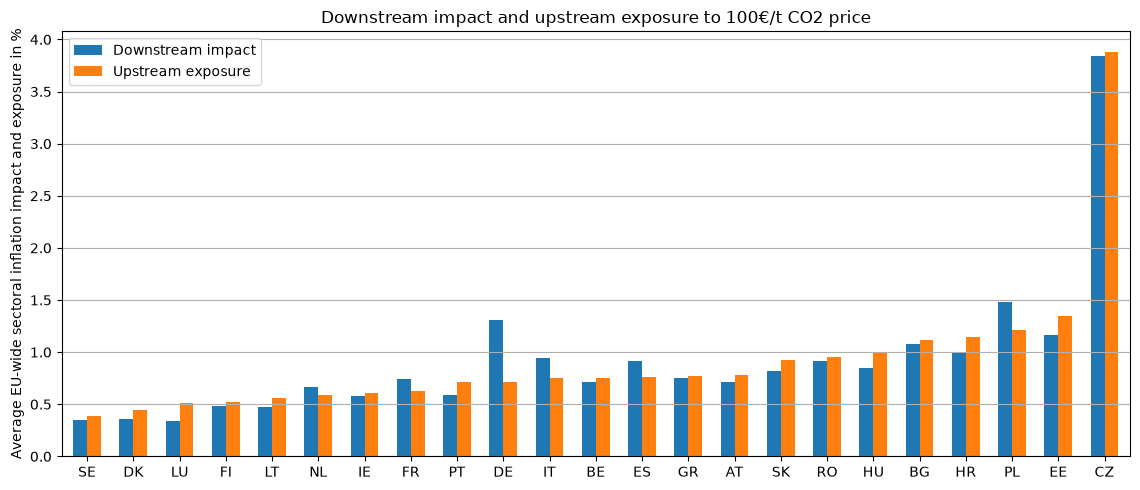

In [437]:

df["csd_aggr"] = dP_csd.sum(on="sectors").data /len(sectors)
df["rec_aggr"] = dP_rec.sum(on="sectors").data /len(sectors)

df_sorted = df.sort_values(by="rec_aggr")

ax = df_sorted[["csd_aggr", "rec_aggr"]].plot.bar(
    figsize=(0.5 * len(countries), 5),
    rot=0,
    width=0.6, 
    title="Downstream impact and upstream exposure to 100€/t CO2 price",
)
ax.grid(axis="y") 
ax.set_ylabel("Average EU-wide sectoral inflation impact and exposure in %")
ax.legend(["Downstream impact", "Upstream exposure"])#

plt.tight_layout()
plt.savefig(os.path.join(figure_path, "bar_average_regional_impact_exposure.png"), bbox_inches='tight', dpi=300)
plt.show()

## Heatmaps

### Absolute deltaP by sector

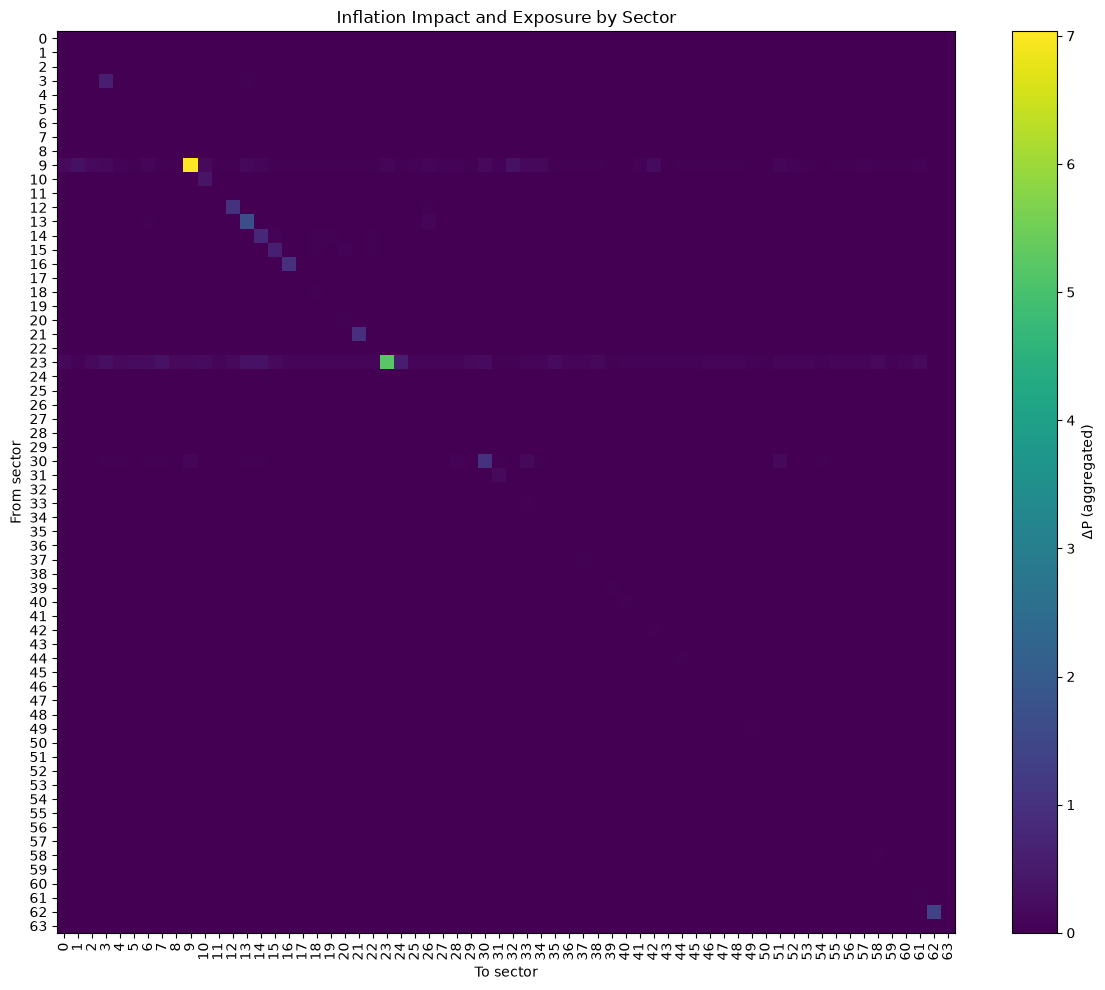

In [438]:
values = P["DE", "DE"].sum(on="countries").data
n_rows, n_cols = values.shape

plt.figure(figsize=(12, 10))
plt.imshow(values, cmap='viridis', aspect='auto')

plt.xticks(ticks=np.arange(n_cols), rotation=90)
plt.yticks(ticks=np.arange(n_rows))

plt.colorbar(label='ΔP (aggregated)')
plt.title("Inflation Impact and Exposure by Sector")
plt.xlabel("To sector")
plt.ylabel("From sector")
plt.tight_layout()
plt.show()
plt.show()

### Normalized deltaP by sector

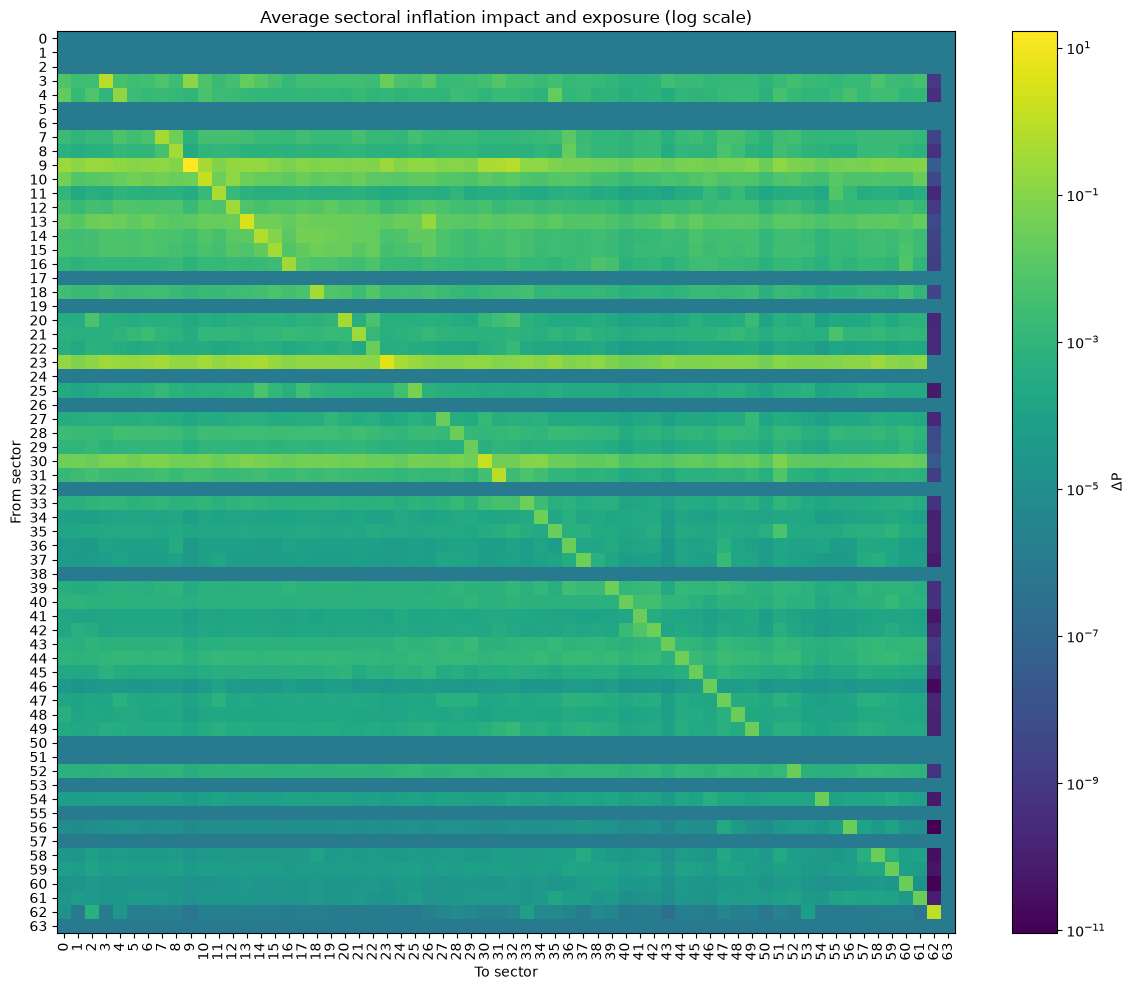

In [439]:
values = abs(P.sum(on = "countries").data)/len(countries)
values[values == 0] = 1e-6  # Avoid log(0) by replacing zeros with a small value

n_rows, n_cols = values.shape

plt.figure(figsize=(12, 10))
plt.imshow(values, cmap='viridis', aspect='auto', norm=LogNorm())

# Set all ticks and labels
plt.xticks(ticks=np.arange(n_cols), rotation=90)
plt.yticks(ticks=np.arange(n_rows))


plt.colorbar(label='ΔP')
plt.title("Average sectoral inflation impact and exposure (log scale)")
plt.xlabel("To sector")
plt.ylabel("From sector")
plt.tight_layout()
#plt.savefig(os.path.join(figure_path, "heatmap_sectors_normalized.png"), bbox_inches='tight', dpi=300)
plt.show()


### Normalized deltaP by country and sector

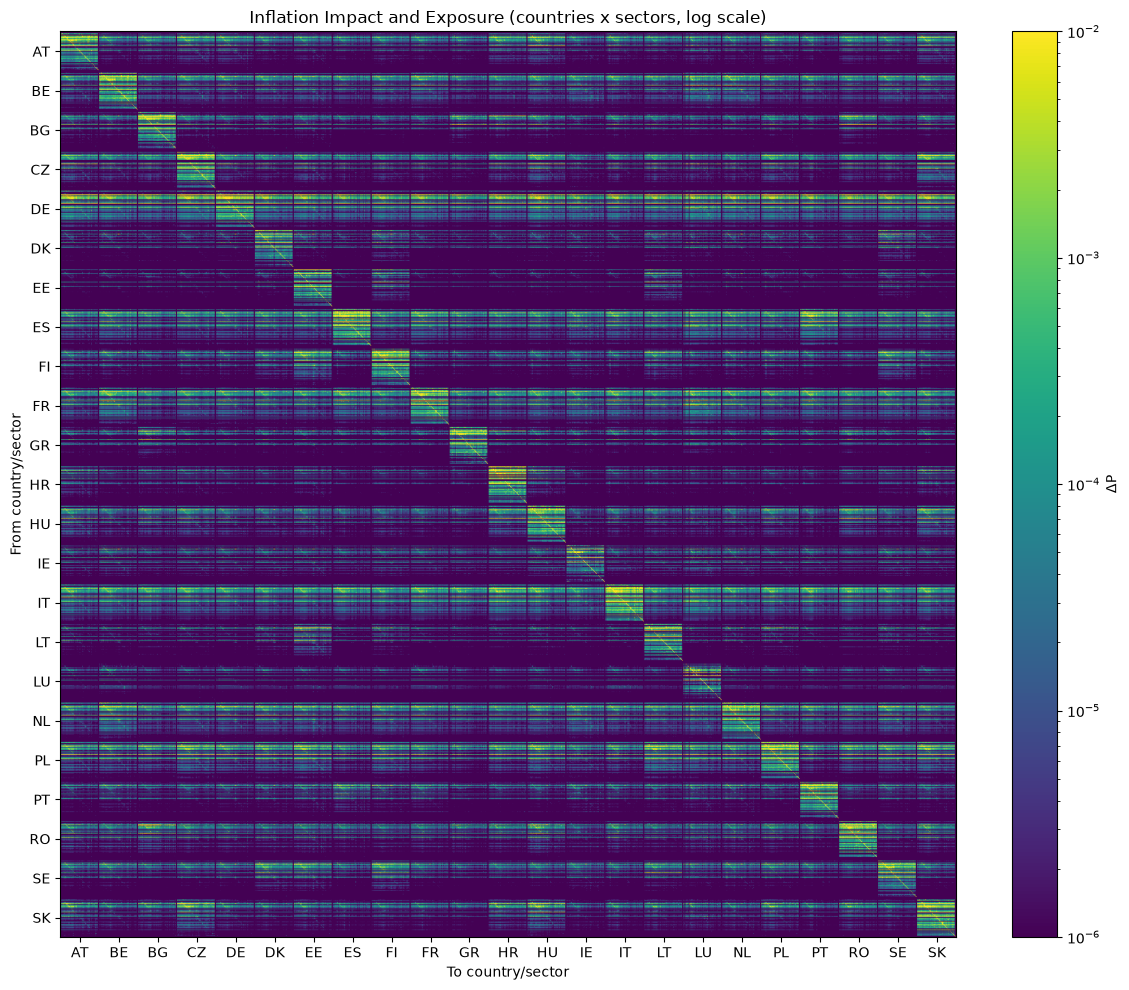

In [440]:
values = abs(P.data)
values[values == 0] = 1e-6  # Avoid log(0)
values[values < 1e-6] = 1e-6
values[values > 0.01] = 0.01 

n_rows, n_cols = values.shape

# Assuming 64 sectors per country
sectors_per_country = 64
num_countries_x = n_cols // sectors_per_country
num_countries_y = n_rows // sectors_per_country

# Centered tick positions
x_ticks = np.arange(sectors_per_country // 2, n_cols, sectors_per_country)
y_ticks = np.arange(sectors_per_country // 2, n_rows, sectors_per_country)

# Labels (truncate if necessary)
x_labels = countries[:len(x_ticks)]
y_labels = countries[:len(y_ticks)]

plt.figure(figsize=(12, 10))
plt.imshow(values, cmap='viridis', aspect='auto', norm=LogNorm())

plt.colorbar(label='ΔP')
plt.title("Inflation Impact and Exposure (countries x sectors, log scale)")
plt.xlabel("To country/sector")
plt.ylabel("From country/sector")

# Centered country labels
plt.xticks(ticks=x_ticks, labels=x_labels)
plt.yticks(ticks=y_ticks, labels=y_labels)

plt.tight_layout()
#plt.savefig(os.path.join(figure_path, "heatmap_countries_sectors.png"), bbox_inches='tight', dpi=300)
plt.show()


#### Index mapping

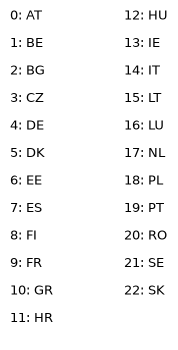

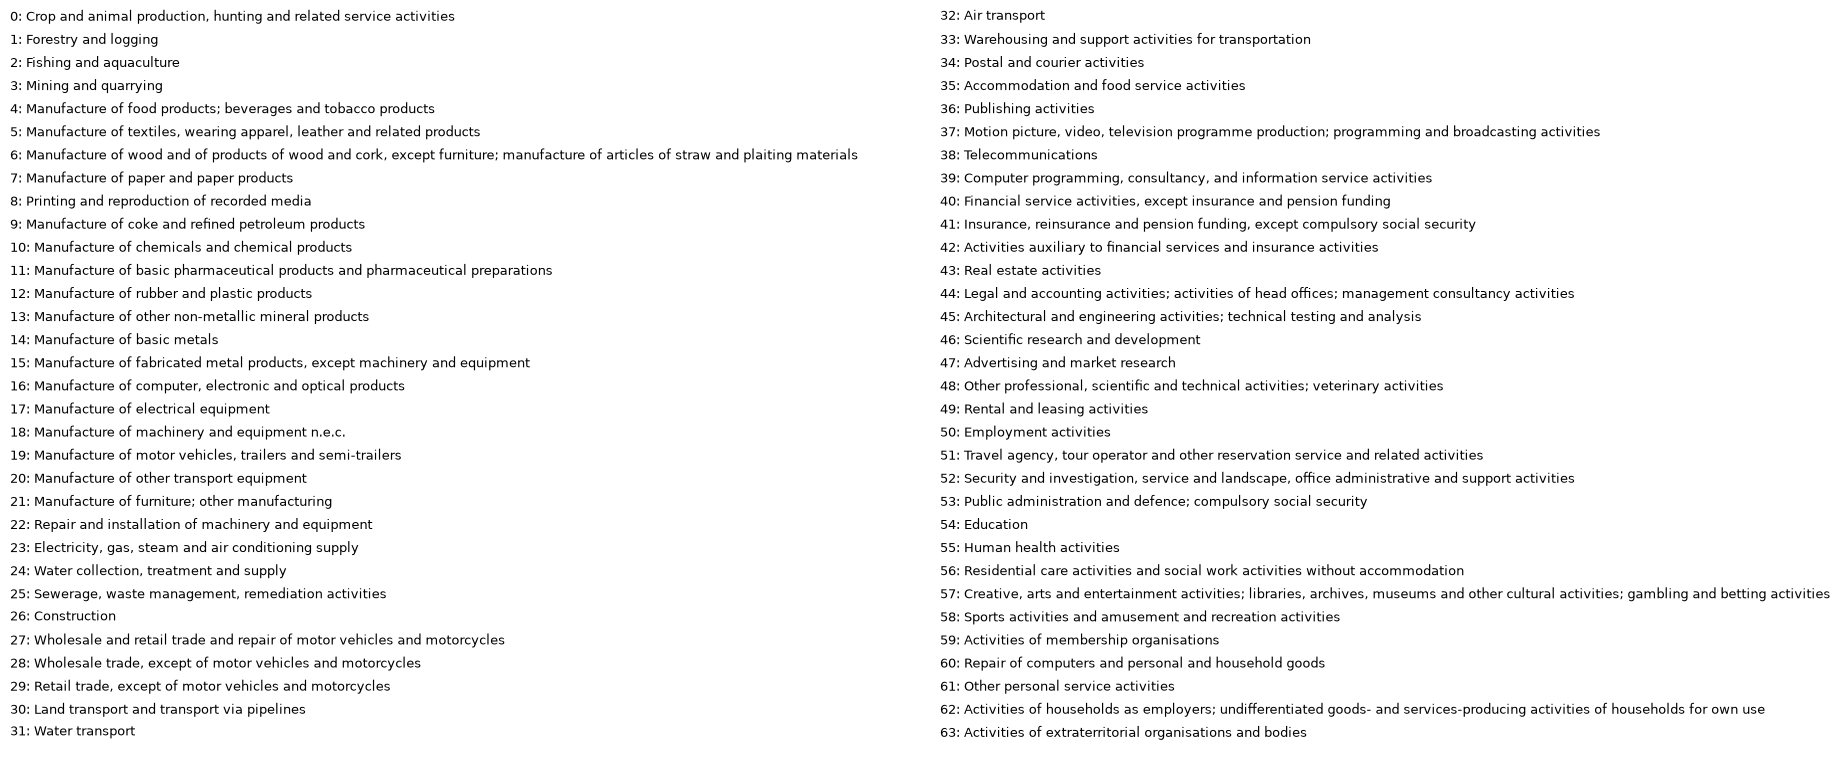

In [441]:
n = len(countries)
n_cols = 2
n_rows = (n + 1) // n_cols  
plt.figure(figsize=(2, n_rows * 0.3)) 
plt.axis('off') 
for i, country in enumerate(countries):
    col = i // n_rows  
    row = i % n_rows
    x = col * 1.2 
    y = 1 - row / n_rows
    plt.text(x, y, f"{i}: {country}", fontsize=9, ha='left', va='top')
plt.tight_layout()
plt.savefig(os.path.join(figure_path, "countries_list.png"), bbox_inches='tight', dpi=300)
plt.show()


n = len(sectors)
n_cols = 2
n_rows = (n + 1) // n_cols  
plt.figure(figsize=(10, n_rows * 0.3)) 
plt.axis('off')  
for i, sector in enumerate(sectors):
    col = i // n_rows 
    row = i % n_rows
    x = col * 1.2 
    y = 1 - row / n_rows
    plt.text(x, y, f"{i}: {sector}", fontsize=9, ha='left', va='top')
plt.tight_layout()
plt.savefig(os.path.join(figure_path, "sectors_list.png"), bbox_inches='tight', dpi=300)
plt.show()

## Actual national HICP inflation
### Direct and indirect effects

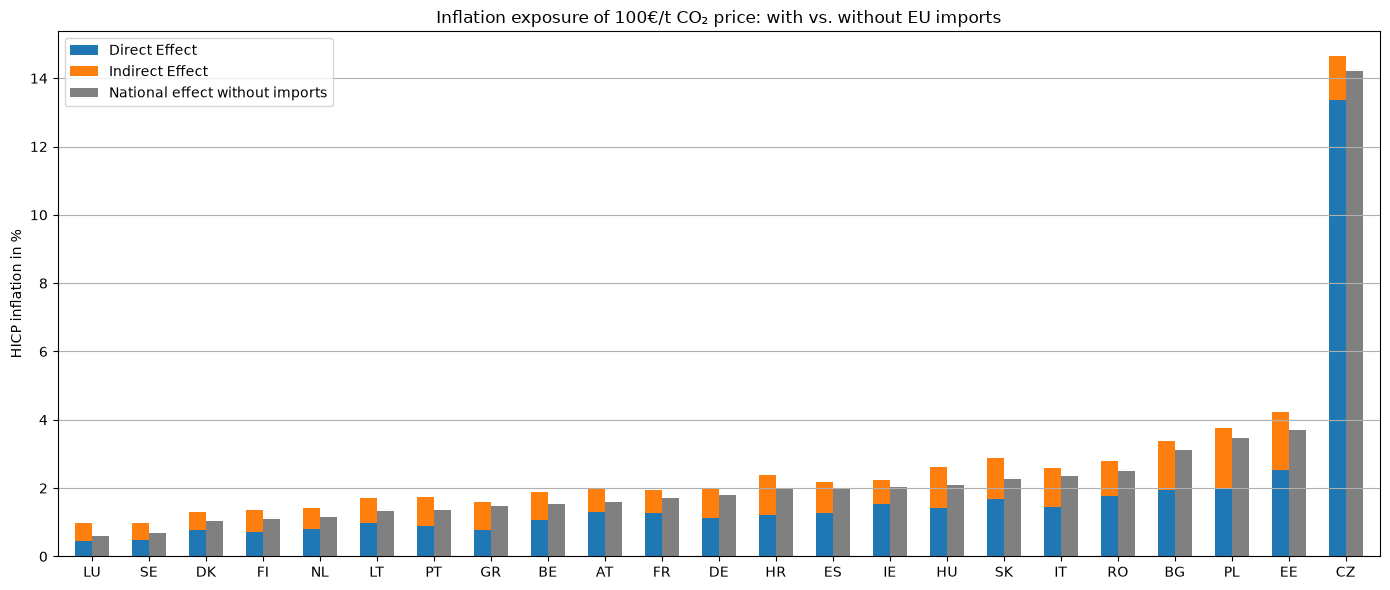

In [442]:
# 1. Sort and extract data
df_sorted = df.sort_values("rec_nat_hicp")
sorted_countries = df_sorted.index

direct = df_sorted["rec_d_hicp"].values
indirect = df_sorted["rec_i_hicp"].values
national = df_sorted["rec_nat_hicp"].values

x = np.arange(len(sorted_countries)) 
width = 0.3  # Width of each bar group

fig, ax = plt.subplots(figsize=(14, 6))

bar1 = ax.bar(x - width/2, direct, width)
bar2 = ax.bar(x - width/2, indirect, width, bottom=direct)
bar3 = ax.bar(x + width/2, national, width, color="grey")

ax.set_xticks(x)
ax.set_xticklabels(sorted_countries)
ax.set_ylabel("HICP inflation in %")
ax.set_title("Inflation exposure of 100€/t CO₂ price: with vs. without EU imports")
ax.grid(axis='y')
ax.legend(["Direct Effect", "Indirect Effect", "National effect without imports"])
ax.set_xlim(-0.6, len(x) - 0.4)# reduce left and right margins

plt.tight_layout()
plt.savefig(os.path.join(figure_path, "bar_hicp_direct_indirect_national.png"), bbox_inches='tight', dpi=300)
plt.show()

### Imported Inflation

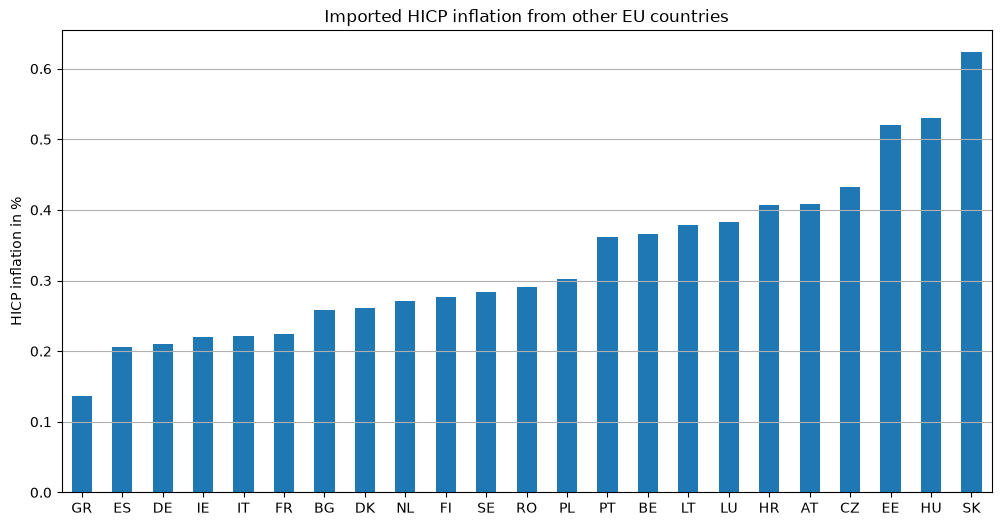

In [443]:
ax = df.sort_values("rec_from_foreign")["rec_from_foreign"].plot.bar(figsize=(12, 6), rot=0
)
ax.set_ylabel("HICP inflation in %")
ax.set_title("Imported HICP inflation from other EU countries")
ax.grid(axis='y')
#plt.savefig(os.path.join(figure_path, "bar_hicp_imported_inflation.png"), bbox_inches='tight', dpi=300)
plt.show()

## Scatterplot

### Average emission intensity

In [451]:
df.loc["AT"]["avg_q"]

np.float64(5533.695300117983)

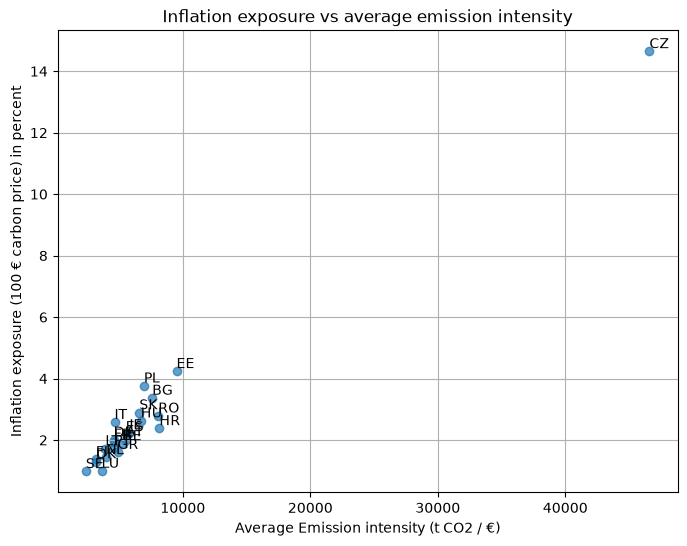

In [452]:
# scatter plot of exposure vs average emissions
plt.figure(figsize=(8, 6))
plt.scatter(df["avg_q"], df["rec_hicp"], alpha=0.7)
plt.title("Inflation exposure vs average emission intensity")
plt.xlabel("Average Emission intensity (t CO2 / €)")
plt.ylabel("Inflation exposure (100 € carbon price) in percent")
plt.grid()
for country in df.index:
    plt.annotate(country, (df.loc[country]["avg_q"], df.loc[country]["rec_hicp"]), fontsize=10, ha='left', va='bottom') 
plt.savefig(os.path.join(figure_path, "scatter_inflation_vs_emission_intensity.png"), bbox_inches='tight', dpi=300)
plt.show()

### Inflation exposure vs GDP per capita

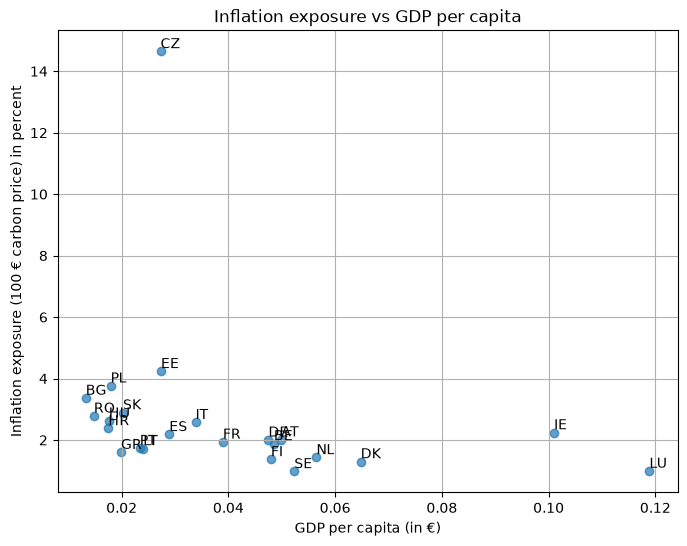

In [453]:
# plot inflation exposure vs GDP per capita
plt.figure(figsize=(8, 6))
plt.scatter(df["GDP_per_capita"], df["rec_hicp"], alpha=0.7)
plt.title("Inflation exposure vs GDP per capita")
plt.xlabel("GDP per capita (in €)")
plt.ylabel("Inflation exposure (100 € carbon price) in percent")
plt.grid()
for i, country in enumerate(df.index):
    plt.annotate(country, (df.loc[country]["GDP_per_capita"], df.loc[country]["rec_hicp"]), fontsize=10, ha='left', va='bottom') 
plt.savefig(os.path.join(figure_path, "scatter_inflation_vs_gdp_per_capita.png"), bbox_inches='tight', dpi=300)
plt.show()

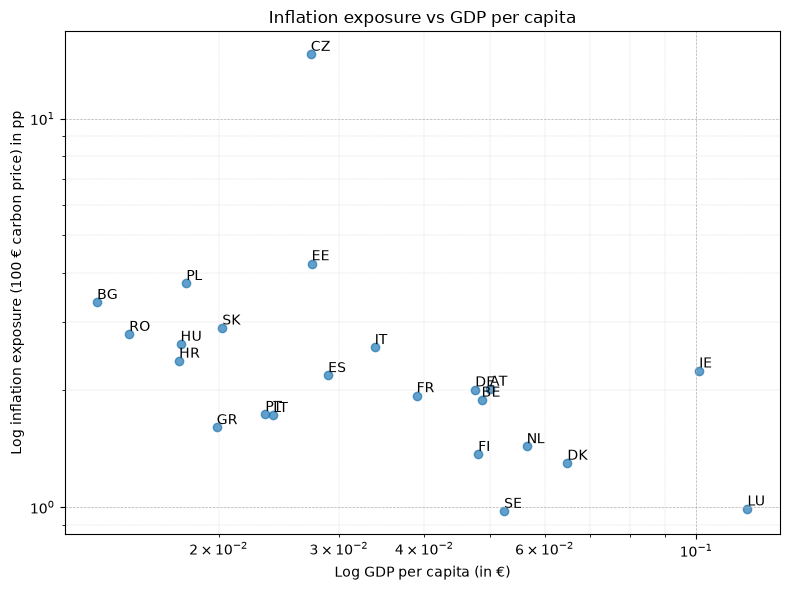

In [455]:
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(df["GDP_per_capita"], df["rec_hicp"], alpha=0.7)

ax.set_title("Inflation exposure vs GDP per capita")
ax.set_xlabel("Log GDP per capita (in €)")
ax.set_ylabel("Log inflation exposure (100 € carbon price) in pp")

# Set log scales
ax.set_xscale('log')
ax.set_yscale('log')

# Grid (major + minor)
ax.grid(which='both', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle=':', linewidth=0.3)

# Annotate country names
for i, country in enumerate(df.index):
    plt.annotate(country, (df.loc[country]["GDP_per_capita"], df.loc[country]["rec_hicp"]), fontsize=10, ha='left', va='bottom') 
    

plt.tight_layout()
plt.savefig(os.path.join(figure_path, "scatter_inflation_vs_gdp_per_capita_log.png"), bbox_inches='tight', dpi=300)
plt.show()


## Maps

### Map of inflation exposure

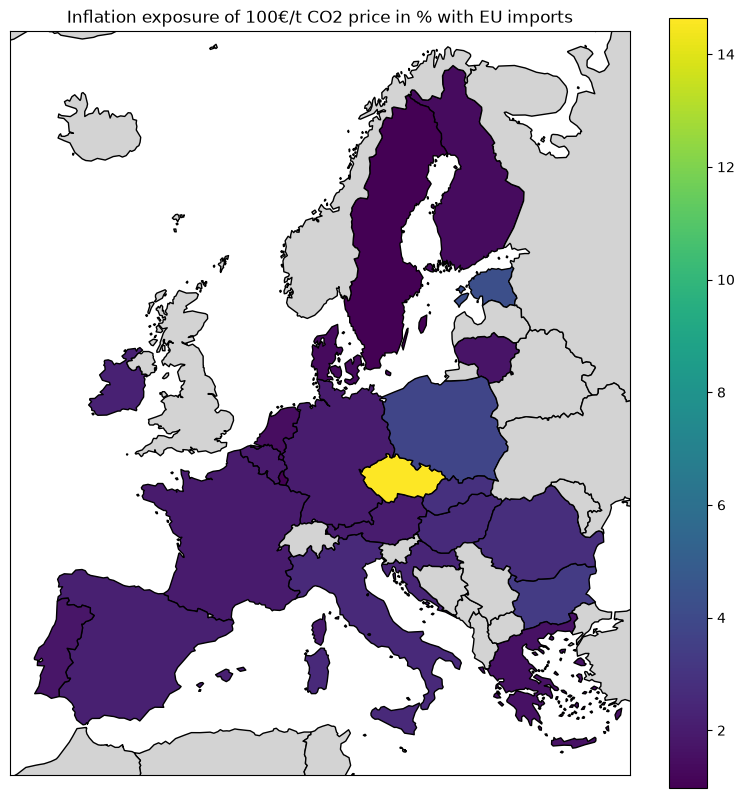

In [456]:
gdf = gpd.read_file("../data/geodata/CNTR_RG_20M_2024_3035.gpkg")
# rename EL to GR in the GeoDataFrame
gdf["CNTR_ID"] = gdf["CNTR_ID"].replace({"EL": "GR"})
gdf = gdf.merge(df, left_on="CNTR_ID", right_index=True, how="left")

ax = gdf.plot(column='rec_hicp', 
              cmap='viridis',       
              legend=True,           
              figsize=(10, 10),
              missing_kwds={'color': 'lightgrey'},
              edgecolor='black')

# Set axis limits to only display the EU region
ax.set_xlim(2500000, 6000000)
ax.set_ylim(1300000, 5500000)
plt.title("Inflation exposure of 100€/t CO2 price in % with EU imports")
ax.set_xticks([])
ax.set_yticks([])
plt.savefig(os.path.join(figure_path, "map_hicp.png"), bbox_inches='tight', dpi=300)
plt.show()

### Maps of household emissions: Heating

In [ ]:
titles = {
    "hh_heat": "Household heating emissions in t CO2",
    "hh_heat_GDP": "Household heating emissions in t CO2 per million euro of GDP",
    "hh_heat_Capita": "Household heating emissions in t CO2 per capita",
    "hh_transport": "Household transport emissions in t CO2",
    "hh_transport_GDP": "Household transport emissions in t CO2 per million euro of GDP",
    "hh_transport_Capita": "Household transport emissions in t CO2 per capita",
    "hh_oth": "Household other emissions in t CO2",
    "hh_oth_GDP": "Household other emissions in t CO2 per million euro of GDP",
    "hh_oth_Capita": "Household other emissions in t CO2 per",
    "hh_total": "Total household emissions in t CO2",
    "hh_total_GDP": "Total household emissions in t CO2 per million euro of GDP",
    "hh_total_Capita": "Total household emissions in t CO2 per capita",
}

Todo: think about whether we need household emission maps. We could build household emissions from the IPCC categories (residential + car emissions) 

In [463]:
"""for statistic in ["hh_heat", "hh_heat_Capita", "hh_heat_GDP"]:
    ax = gdf.plot(column=statistic, 
                  cmap='viridis',       
                  legend=True,           
                  figsize=(10, 10),
                  missing_kwds={'color': 'lightgrey'},
                  edgecolor='black')

    # Set axis limits to only display the EU region
    ax.set_xlim(2500000, 6000000)
    ax.set_ylim(1300000, 5500000)
    plt.title(titles[statistic])
    ax.set_xticks([])
    ax.set_yticks([])
    plt.savefig(os.path.join(figure_path, f"map_{statistic}.png"), bbox_inches='tight', dpi=300)
    plt.show()"""

'for statistic in ["hh_heat", "hh_heat_Capita", "hh_heat_GDP"]:\n    ax = gdf.plot(column=statistic, \n                  cmap=\'viridis\',       \n                  legend=True,           \n                  figsize=(10, 10),\n                  missing_kwds={\'color\': \'lightgrey\'},\n                  edgecolor=\'black\')\n\n    # Set axis limits to only display the EU region\n    ax.set_xlim(2500000, 6000000)\n    ax.set_ylim(1300000, 5500000)\n    plt.title(titles[statistic])\n    ax.set_xticks([])\n    ax.set_yticks([])\n    plt.savefig(os.path.join(figure_path, f"map_{statistic}.png"), bbox_inches=\'tight\', dpi=300)\n    plt.show()'

### Maps of household emissions: Transport

In [464]:
"""for statistic in ["hh_transport", "hh_transport_Capita", "hh_transport_GDP"]:
    ax = gdf.plot(column=statistic, 
                  cmap='viridis',       
                  legend=True,           
                  figsize=(10, 10),
                  missing_kwds={'color': 'lightgrey'},
                  edgecolor='black')

    # Set axis limits to only display the EU region
    ax.set_xlim(2500000, 6000000)
    ax.set_ylim(1300000, 5500000)
    plt.title(titles[statistic])
    ax.set_xticks([])
    ax.set_yticks([])
    plt.show()"""

'for statistic in ["hh_transport", "hh_transport_Capita", "hh_transport_GDP"]:\n    ax = gdf.plot(column=statistic, \n                  cmap=\'viridis\',       \n                  legend=True,           \n                  figsize=(10, 10),\n                  missing_kwds={\'color\': \'lightgrey\'},\n                  edgecolor=\'black\')\n\n    # Set axis limits to only display the EU region\n    ax.set_xlim(2500000, 6000000)\n    ax.set_ylim(1300000, 5500000)\n    plt.title(titles[statistic])\n    ax.set_xticks([])\n    ax.set_yticks([])\n    plt.show()'

### Maps of household emissions: Total
This includes heating, transport and 'other' emissions. 

In [465]:
"""for statistic in ["hh_total", "hh_total_Capita", "hh_total_GDP"]:
    ax = gdf.plot(column=statistic, 
                  cmap='viridis',       
                  legend=True,           
                  figsize=(10, 10),
                  missing_kwds={'color': 'lightgrey'},
                  edgecolor='black')

    # Set axis limits to only display the EU region
    ax.set_xlim(2500000, 6000000)
    ax.set_ylim(1300000, 5500000)
    plt.title(titles[statistic])
    ax.set_xticks([])
    ax.set_yticks([])
    plt.savefig(os.path.join(figure_path, f"map_{statistic}.png"), bbox_inches='tight', dpi=300)
    plt.show()"""

'for statistic in ["hh_total", "hh_total_Capita", "hh_total_GDP"]:\n    ax = gdf.plot(column=statistic, \n                  cmap=\'viridis\',       \n                  legend=True,           \n                  figsize=(10, 10),\n                  missing_kwds={\'color\': \'lightgrey\'},\n                  edgecolor=\'black\')\n\n    # Set axis limits to only display the EU region\n    ax.set_xlim(2500000, 6000000)\n    ax.set_ylim(1300000, 5500000)\n    plt.title(titles[statistic])\n    ax.set_xticks([])\n    ax.set_yticks([])\n    plt.savefig(os.path.join(figure_path, f"map_{statistic}.png"), bbox_inches=\'tight\', dpi=300)\n    plt.show()'